In [1]:
from river_model import RiverModel

[ To do ] Add description for model configuration below

In [2]:
from constants import N_SIZE_NETWORK, MAT_NETWORK, N_LONGEST_PATH

In [3]:
from constants import D_T, N_ITER, VEC_T
from constants import QIN_TS, Q_T0

In [4]:
from constants import VEC_TOBS

## Model

Explications, illustration ...

### Instanciate model + free run : State variables : Q

In [5]:
forward_model = RiverModel(par_k_in = 0.5, par_x_in = 0.3)

In [6]:
q_out_ts = forward_model.run()

### Diagnostic variables : H

Known law relating Q and H

In [7]:
h_out_ts = forward_model.estimate_height(q_out_ts)

/work/CAMPUS/users/emerych/git/VSEO-6-Training-Sessions-Data-Assimilation/river_model.py:225: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--k" (-> color='k'). The keyword argument will take precedence.
  ax.plot(mat_q_in_ts[k,:], "--k", color=(0.0, 0.0, 0.75), linewidth=0.75, label="Qin")
/work/CAMPUS/users/emerych/git/VSEO-6-Training-Sessions-Data-Assimilation/river_model.py:232: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-b" (-> color='b'). The keyword argument will take precedence.
  ax_bis.plot(h_out_ts[k, :], "-b", color=(0.75, 0., 0.75), label="Hout")


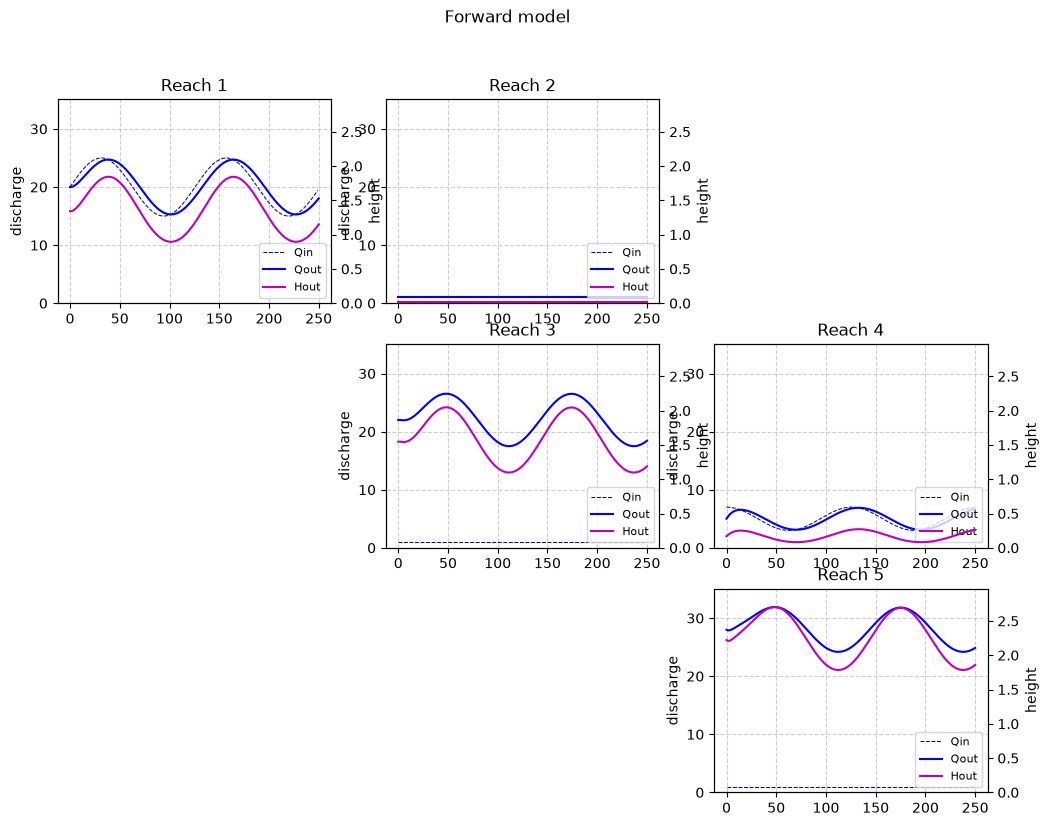

In [8]:
forward_model.plot(q_out_ts, h_out_ts, title="Forward model")

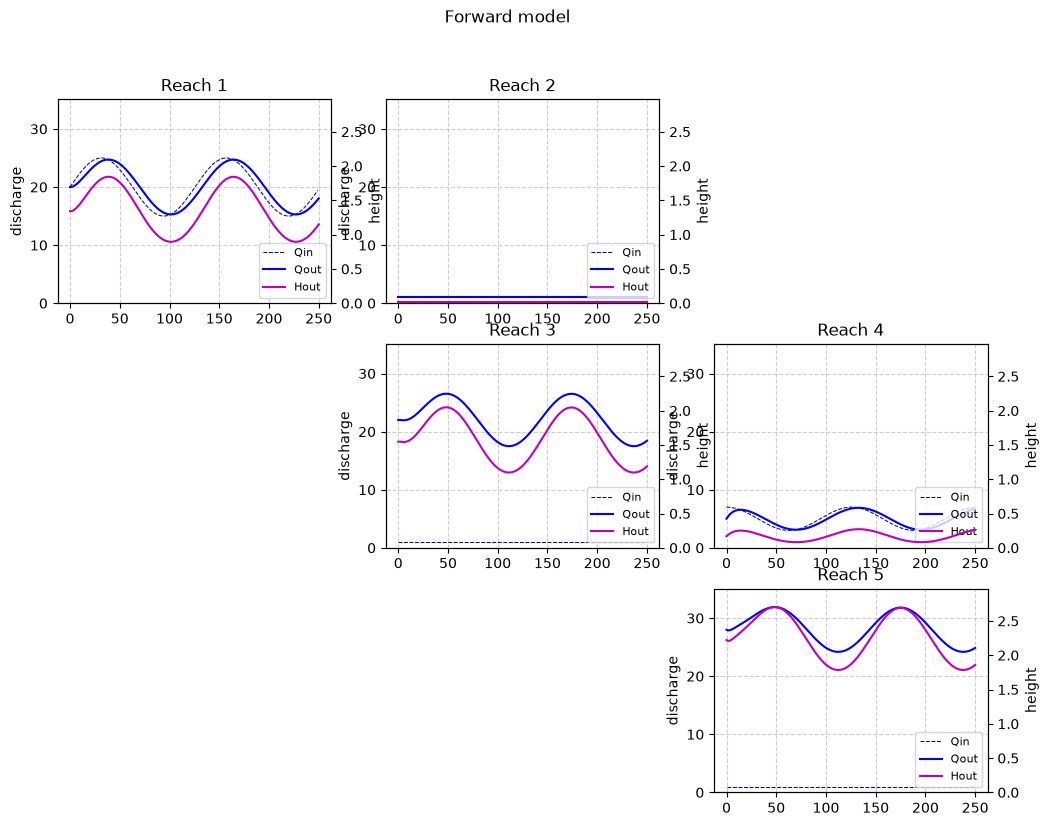

In [10]:
# Play with the model

k = 1.2 # Must be in [0.5, 1.5]
x = 0.3 # Must be in [0.1, 0.3]
qin_mul = 1.5 # Must be in [0.25, 1.5]

test_model = RiverModel(par_k_in = k, par_x_in = x, par_qin_mul=qin_mul)
q_out_ts = forward_model.run()
h_out_ts = forward_model.estimate_height(q_out_ts)
forward_model.plot(q_out_ts, h_out_ts, title="Forward model")

## Observations

### Available observations set

In [11]:
dct_obs_1 = {
    "yobs": [ 28.031, 31.354, 28.918, 26.057, 25.365, 26.536, 29.751, 30.046, 26.028, 26.167 ],
    "variable": "q",
    "reach": [5]
}

In [12]:
dct_obs_2 = {
    "yobs": [ 2.345, 2.594, 2.340, 2.028, 1.921, 2.086, 2.391, 2.312, 2.029, 1.949 ],
    "variable": "h",
    "reach": [5]
}

In [13]:
dct_obs_3 = {
    "yobs": [ 21.910, 26.992, 24.554, 19.885, 17.863, 19.427, 26.036, 23.850, 20.655, 19.492 ],
    "variable": "q",
    "reach": [3]
}

### Model vs observations

/work/CAMPUS/users/emerych/git/VSEO-6-Training-Sessions-Data-Assimilation/bayes_estimator.py:72: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-b" (-> color='b'). The keyword argument will take precedence.
  ax_bis.plot(h_out_ts[k, :], "-b", color=(0.75, 0., 0.75), label="H free run")


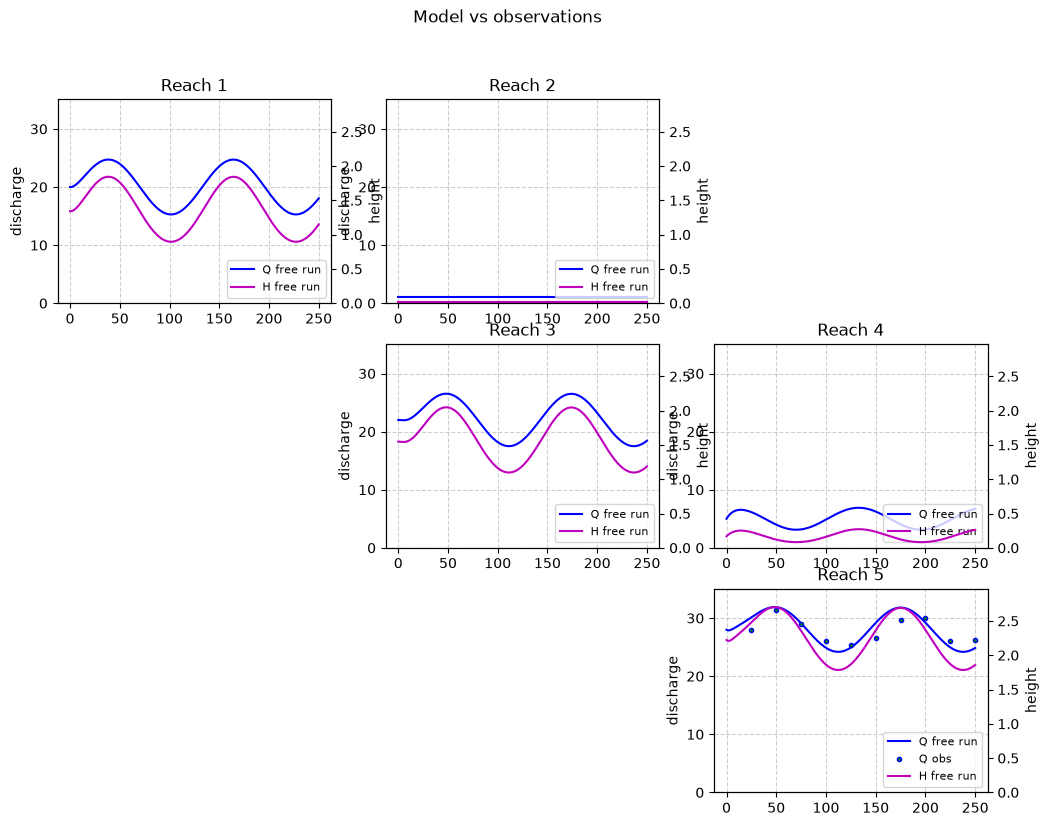

In [14]:
from bayes_estimator import DAExperiment
assim_base = DAExperiment(forward_model=forward_model,
                        dct_obs=dct_obs_1)
assim_base.plot_model_vs_obs()

### [Bonus #1] Sensitivity analysis - focus on (k,x) parameters

/work/scratch/env/emerych/.conda/envs/sig_py314/lib/python3.14/site-packages/SALib/analyze/sobol.py:216: UserWarning: Constant values encountered, indicating model evaluations (or subset of evaluations) produced identical values.
  warn(CONST_RESULT_MSG)
/work/CAMPUS/users/emerych/git/VSEO-6-Training-Sessions-Data-Assimilation/sensitivity_analysis.py:140: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-k" (-> color='k'). The keyword argument will take precedence.
  axis[0, 0].plot(self._q_out_e[i, :, k], '-k', color=(0.5, 0.5, 0.5), linewidth=0.5)
/work/CAMPUS/users/emerych/git/VSEO-6-Training-Sessions-Data-Assimilation/sensitivity_analysis.py:147: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-k" (-> color='k'). The keyword argument will take precedence.
  axis[0, 1].plot(self._h_out_e[i, :, k], '-k', color=(0.5, 0.5, 0.5), linewidth=0.5)


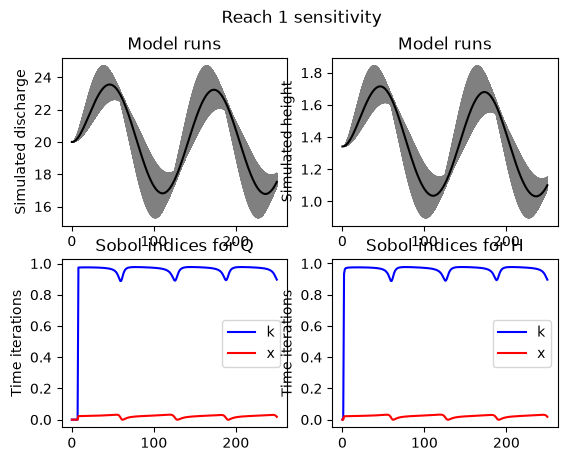

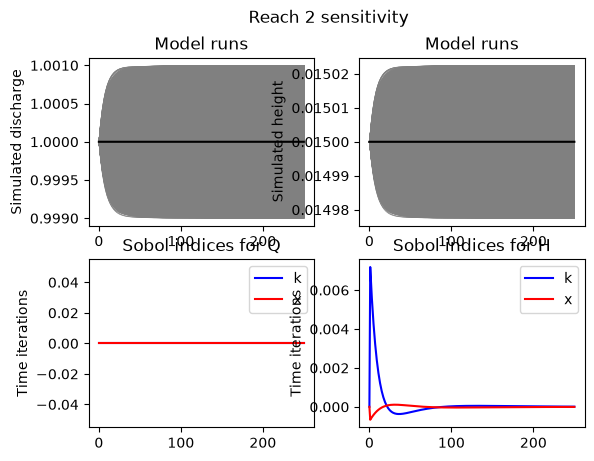

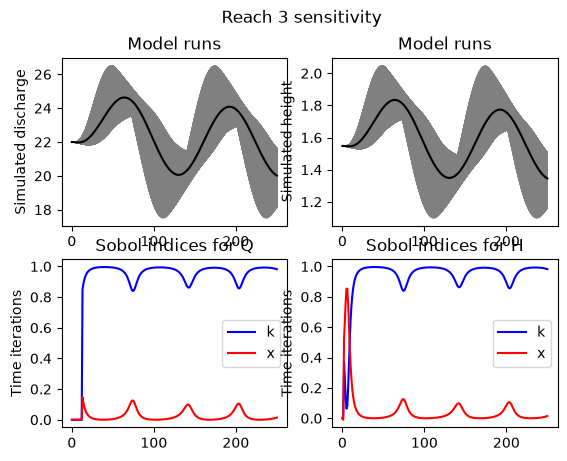

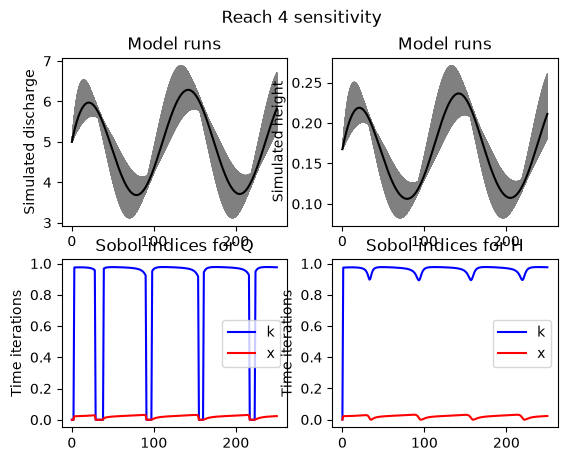

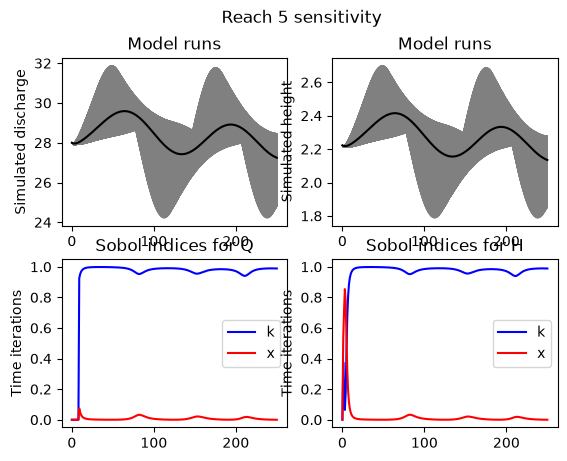

In [15]:
from sensitivity_analysis import SensitivityAnalysisRiver
my_analysis = SensitivityAnalysisRiver()
my_analysis.generate_sample()
my_analysis.generate_outputs_ensemble()
my_analysis.estimate_sobol_ensemble()
my_analysis.plot_sensitivity_indices()

### [Bonus #2] Sensitivity analysis - (k,x) parameters + inflow

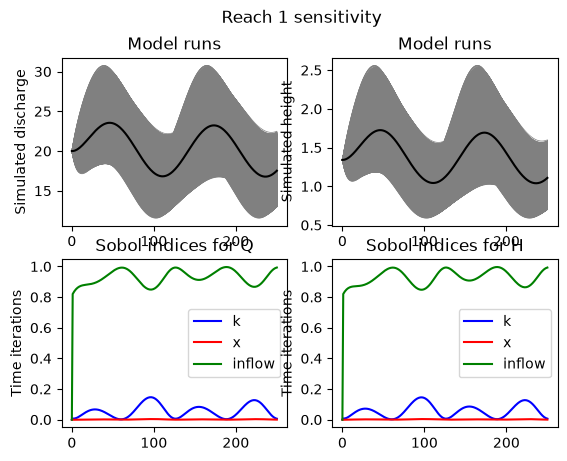

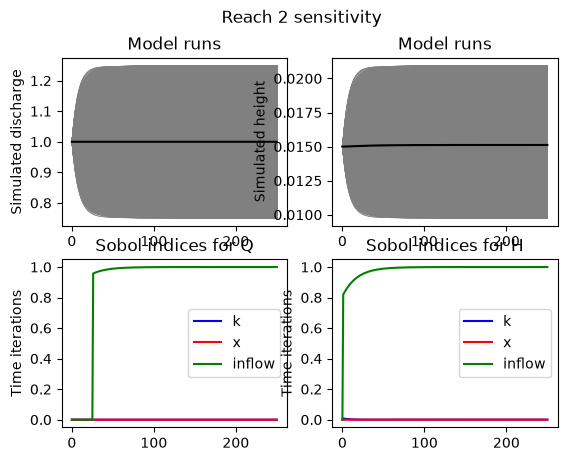

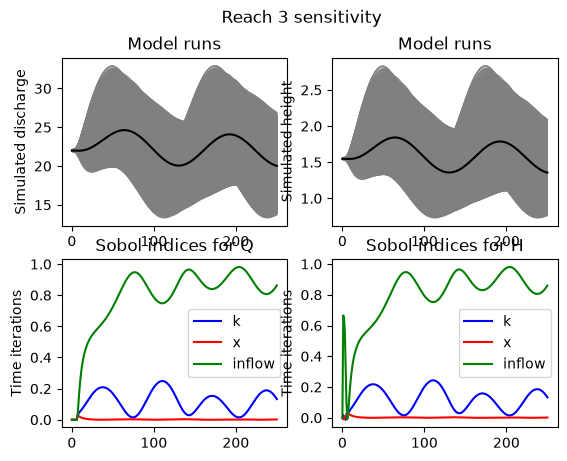

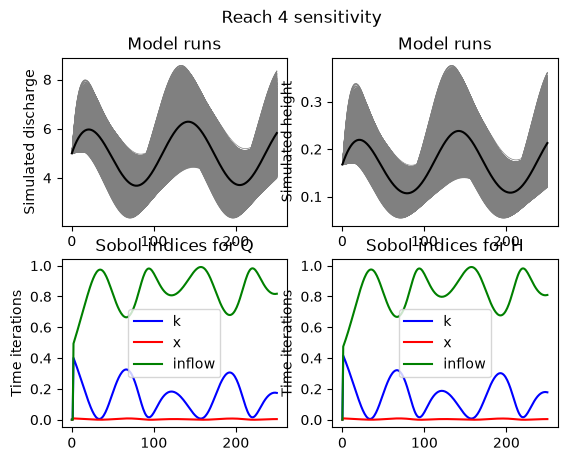

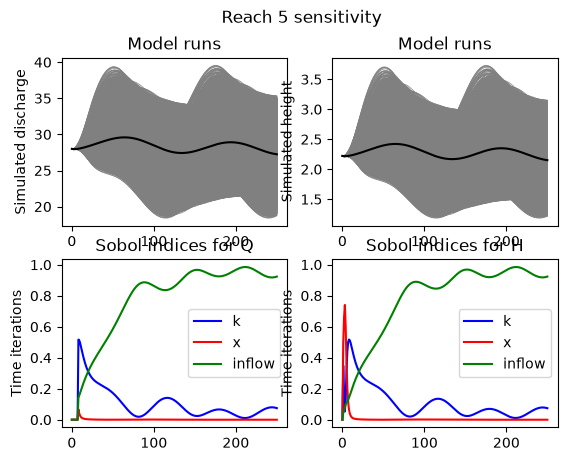

In [16]:
my_analysis = SensitivityAnalysisRiver(bool_qin=True)
my_analysis.generate_sample()
my_analysis.generate_outputs_ensemble()
my_analysis.estimate_sobol_ensemble()
my_analysis.plot_sensitivity_indices()

## Build your data assimilation experiment
# Control : what we want to correct = what is the most uncertain in the model // which inputs the observations can help correct
- state estimation -> directly correct the model state == model initial condition
- parameter estimation -> correct model parameters or inflow condition == model calibration
- "diagnostic" estimation -> like state estimation
# Observation : how the observations are related to the model state/diagnostic varaiables // the parameters

## State estimation

### Control

In [17]:
dct_ctl = {"exp": "state"}

### Observations

In [18]:
dct_obs = dct_obs_1

### Sequential state estimation

In [19]:
state_assim = DAExperiment(forward_model=forward_model, dct_obs=dct_obs_3, dct_ctl=dct_ctl)

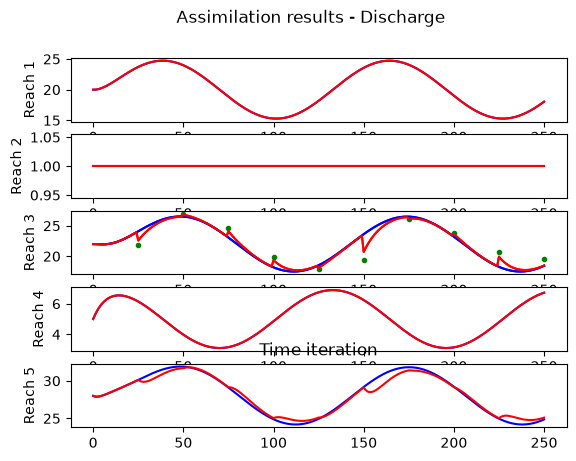

In [20]:
state_assim.sig_o = 0.5
state_assim.sig_b = 0.75
state_assim.perform_assim()
## Ajouter calcul de statistiques

In [ ]:
from constants import SIG_B_Q, SIG_O_Q
import numpy as np
B_in = np.array([
        [SIG_B_Q**2., 0., 0., 0., SIG_B_Q**2.*0.0625],
        [0., SIG_B_Q**2., 0., 0., SIG_B_Q**2.*0.125],
        [0., 0., SIG_B_Q**2., 0., SIG_B_Q**2.*0.25],
        [0., 0., 0., SIG_B_Q**2., SIG_B_Q**2.*0.5],
        [SIG_B_Q**2.*0.0625, SIG_B_Q**2.*0.125, SIG_B_Q**2.*0.25, SIG_B_Q**2.*0.5, SIG_B_Q**2.]
    ])
state_assim = DAExperiment(forward_model=forward_model, dct_obs=dct_obs_1, dct_ctl=dct_ctl)
state_assim.sig_o = SIG_O_Q
state_assim.sig_b = SIG_B_Q
state_assim.perform_assim(b_in=B_in)

In [ ]:
from constants import SIG_B_K
dct_ctl = {
    "exp": "parameter"
}
param_assim = DAExperiment(forward_model=forward_model, dct_obs=dct_obs_1, dct_ctl=dct_ctl)
param_assim.sig_o = SIG_O_Q
param_assim.sig_b = SIG_B_K
param_assim.perform_assim()